# Selection bias $b_\text{sel}(\theta)$ vs. $\lambda^\text{ob} - \lambda^\text{tr}$

Port of Matteo's Costanzi-2026 `b_sel_lob_ltr_theta` (his cell 16).

$$b_\text{sel}(\theta) = b_\text{sel}^\text{in} + (b_\text{eff} - b_\text{sel}^\text{in}) \cdot \frac{1}{1 + e^{-k(\theta - \theta_0)}}$$

- $b_\text{sel}^\text{in}(\lambda^\text{tr}, z, \lambda^\text{ob}) = (\Delta_\text{prj} - \overline{\Delta_\text{prj}}^\text{bkg}) / \mathcal{N}_2$ — intrinsic small-scale limit.
- $b_\text{eff} = b_\text{eff-ltr}(\lambda^\text{tr}, z) \cdot b_\text{boost}$ — scale-independent large-scale limit.
- $b_\text{boost} = 1$ by default (Matteo's `boost_bias=1.0` fallback; change `inter_boost_bias` / `slope_boost_bias` in the `SelBias` constructor to enable the full model).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from richness_selection import (
    Cosmology, PkGrid, HMF, Bias, MOR, XiNL, SelBias,
)
from richness_selection.sigma_m import SigmaM

cosmo    = Cosmology()
pk       = PkGrid(cosmo)
sigma_m  = SigmaM(pk)
hmf      = HMF(sigma_m)
bias     = Bias(sigma_m)
mor      = MOR()
xi_nl    = XiNL(cosmo)
sel_bias = SelBias(cosmo, pk, hmf, bias, mor, xi_nl=xi_nl)

In [2]:
lob = 20.0
zob = 0.5

pipe = sel_bias.bias_pipeline(lob, zob, 18.0)
print('bias_pipeline(lob=20, zob=0.5, ltr=18):')
for k, v in pipe.items():
    if isinstance(v, float):
        print(f'  {k:>22s} = {v:+.4e}')

bias_pipeline(lob=20, zob=0.5, ltr=18):
                     lob = +2.0000e+01
                     zob = +5.0000e-01
                     ltr = +1.8000e+01
       b_halo_eff_at_lob = +3.4682e+00
            eff_bias_ltr = +3.2809e+00
      bar_delta_prj_Beff = +5.0109e+00
       bar_delta_prj_bkg = +4.6488e+00
              numerator2 = +1.1296e-01
               Delta_prj = +2.0000e+00
                b_sel_in = -2.3449e+01


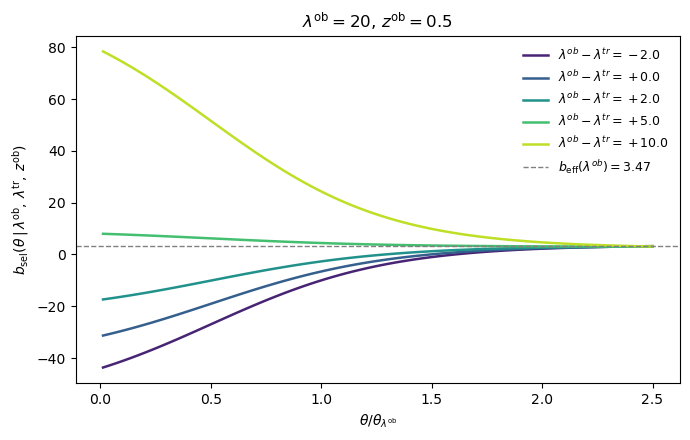

In [3]:
# Sweep lambda^ob - lambda^tr at fixed lob.
deltas = np.array([-2.0, 0.0, 2.0, 5.0, 10.0])   # lob - ltr
ltrs   = lob - deltas

theta_lob = sel_bias._theta_lob(lob, zob)
thetas    = np.linspace(1e-5, 2.5 * theta_lob, 80)

fig, ax = plt.subplots(figsize=(7, 4.5))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(ltrs)))

for col, d, ltr in zip(cmap, deltas, ltrs):
    if ltr <= 0:
        continue
    b = sel_bias.b_sel_lob_ltr_theta(thetas, ltr, zob, lob)
    ax.plot(thetas / theta_lob, b, color=col, lw=1.8,
            label=f'$\\lambda^{{ob}}-\\lambda^{{tr}} = {d:+.1f}$')

b_halo = sel_bias.eff_bias_ltr(lob, zob)
ax.axhline(b_halo, color='0.5', lw=1.0, ls='--',
           label=f'$b_\\mathrm{{eff}}(\\lambda^{{ob}}) = {b_halo:.2f}$')
ax.set_xlabel(r'$\theta / \theta_{\lambda^\mathrm{ob}}$')
ax.set_ylabel(r'$b_\mathrm{sel}(\theta \,|\, \lambda^\mathrm{ob},\, \lambda^\mathrm{tr},\, z^\mathrm{ob})$')
ax.set_title(rf'$\lambda^\mathrm{{ob}}={lob:.0f}$, $z^\mathrm{{ob}}={zob}$')
ax.legend(frameon=False, fontsize=9, loc='best')
fig.tight_layout()
plt.show()

## Marginalised over $\lambda^\text{tr}$

The observable in the likelihood is $\langle b_\text{sel}(\theta) \rangle_{p(\lambda^\text{tr} | \lambda^\text{ob})}$.

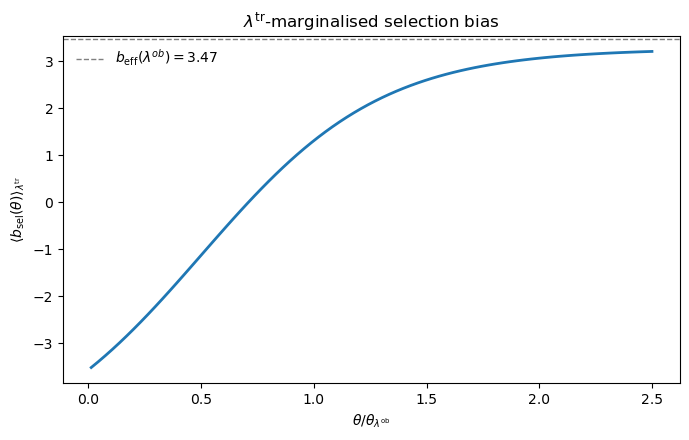

In [4]:
bsel_marg = sel_bias.b_sel_marginalised(thetas, lob, zob)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thetas / theta_lob, bsel_marg, color='C0', lw=2)
ax.axhline(b_halo, color='0.5', lw=1.0, ls='--',
           label=f'$b_\\mathrm{{eff}}(\\lambda^{{ob}}) = {b_halo:.2f}$')
ax.set_xlabel(r'$\theta / \theta_{\lambda^\mathrm{ob}}$')
ax.set_ylabel(r'$\langle b_\mathrm{sel}(\theta)\rangle_{\lambda^\mathrm{tr}}$')
ax.set_title(r'$\lambda^\mathrm{tr}$-marginalised selection bias')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()